# process data for consumer - resource model


> ### Reproducibility &amp; data
>
> This notebook reproduces **data-preprocessing**: builds the MiCRM datasets for training. Heavy arrays are archived on Zenodo; generators are in `../../simulation_code/consumer resource/`.
>
> Notebook **outputs are preserved**, so the results are visible without rerunning. Figure-saving (`savefig`) is disabled for the release; plots still render inline. See the repository `DATA.md` for how to restore Zenodo artifacts.

In [1]:
# We begin by importing the essentials
import numpy as np
from sklearn.model_selection import train_test_split
np.random.seed(42)

In [2]:
numSpecies = 100
numResource = 30
N_Sample = 10000
model_index = 3

NT=np.arange(1,11,1,dtype=int)

species_data = np.loadtxt(f"./saved_sims/I{model_index}/mcrm_species.txt")
resource_data = np.loadtxt(f"./saved_sims/I{model_index}/mcrm_resource.txt")

#sanity check
if N_Sample * numSpecies != species_data.shape[0]:
    print("Error: Sample size do not match.")
    exit()
if N_Sample * numResource != resource_data.shape[0]:
    print("Error: Sample size do not match.")
    exit()
print("Data loaded successfully.")

Data loaded successfully.


# dataset curation

first, we transform the 2-d arrays into 3d (n_sim, n_species, timepoints) / (n_sim, n_resource, timepoints)

In [3]:
species_data_3d = []
for i in range(N_Sample):
    species_sim_i=species_data[i*numSpecies:(i+1)*numSpecies,:]
    species_data_3d.append(species_sim_i)
species_data_3d=np.array(species_data_3d)

resource_data_3d = []
for i in range(N_Sample):
    resource_sim_i=resource_data[i*numResource:(i+1)*numResource,:]
    resource_data_3d.append(resource_sim_i)
resource_data_3d=np.array(resource_data_3d)

Since many species are extinct from the simulation, we sort the community by their cumulative endpoint abundance to avoid trivial dynamics, e.g., exponential decay.

In [4]:
species_cumsum = np.sum(species_data_3d[:, :, -1], axis=0)
print(f"Sanity check: species cumsum size: {species_cumsum.shape}")

# Sort species axis by cumulative endpoint abundance (largest to smallest).
species_sort_idx = np.argsort(species_cumsum)[::-1]
top10_idx = species_sort_idx[:10]
rng = np.random.default_rng(42)
rng.shuffle(top10_idx)
species_data_3d = species_data_3d[:, top10_idx, :]
print(f"Sanity check: sorted endpoint communtity composition: {species_data_3d[0,:,-1]}")

Sanity check: species cumsum size: (100,)
Sanity check: sorted endpoint communtity composition: [ 79564.15686636  61808.48653322 122866.47535531  59258.82170344
  98523.49939944 124290.72593754  87501.18864543  37036.60497596
 133412.73680911  35724.5700877 ]


## quick visualization sanity check

Plot one simulation trajectory and endpoint distributions after sorting/reshaping.

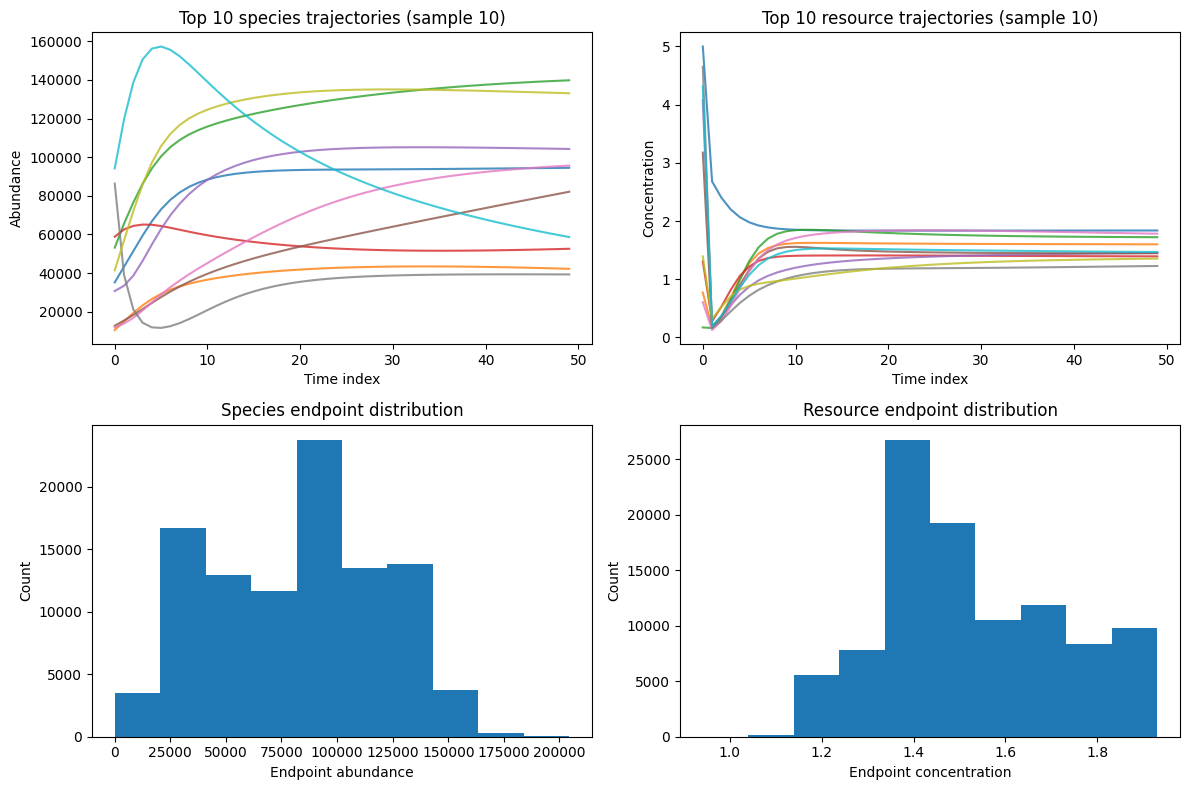

In [5]:
import matplotlib.pyplot as plt

sample_idx = 10
time = np.arange(species_data_3d.shape[-1])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top species trajectories for one sample
n_show_species = min(10, species_data_3d.shape[1])
for j in range(n_show_species):
    axes[0, 0].plot(time, species_data_3d[sample_idx, j, :], alpha=0.8)
axes[0, 0].set_title(f"Top {n_show_species} species trajectories (sample {sample_idx})")
axes[0, 0].set_xlabel("Time index")
axes[0, 0].set_ylabel("Abundance")

# Top resource trajectories for one sample
n_show_resource = min(10, resource_data_3d.shape[1])
for j in range(n_show_resource):
    axes[0, 1].plot(time, resource_data_3d[sample_idx, j, :], alpha=0.8)
axes[0, 1].set_title(f"Top {n_show_resource} resource trajectories (sample {sample_idx})")
axes[0, 1].set_xlabel("Time index")
axes[0, 1].set_ylabel("Concentration")

# Endpoint abundance histogram for species and resources
axes[1, 0].hist(species_data_3d[:, :10, -1].ravel())
axes[1, 0].set_title("Species endpoint distribution")
axes[1, 0].set_xlabel("Endpoint abundance")
axes[1, 0].set_ylabel("Count")

axes[1, 1].hist(resource_data_3d[:, :10, -1].ravel())
axes[1, 1].set_title("Resource endpoint distribution")
axes[1, 1].set_xlabel("Endpoint concentration")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

Based on the sorted dataset (species_data_3d), we generate datasets for each n_target by targeting the first n_target species.

We normalize each n_target dataset by the maximum value, and split into train and test sets. We save the data in .npy format for later use.

In [6]:
# we deal with species data first
for i, n_target in enumerate(NT):
    n_target=NT[i]
    ts_length = species_data.shape[1]
    
    X_species = species_data_3d[:,:n_target,:]

    xmax = np.max(X_species)
    X_species = X_species/xmax
    print(f"{n_target}-target populations; maximum value in the original data: {xmax}, maximum value in the normalized data: {np.max(X_species)}")

    X_train, X_test = train_test_split(X_species, test_size=0.2, random_state=42)
    np.save(f"./saved_sims/I{model_index}/species_T{n_target}_train.npy",X_train)
    np.save(f"./saved_sims/I{model_index}/species_T{n_target}_test.npy",X_test)

1-target populations; maximum value in the original data: 196906.048510512, maximum value in the normalized data: 1.0
2-target populations; maximum value in the original data: 285972.532449565, maximum value in the normalized data: 1.0
3-target populations; maximum value in the original data: 285972.532449565, maximum value in the normalized data: 1.0
4-target populations; maximum value in the original data: 285972.532449565, maximum value in the normalized data: 1.0
5-target populations; maximum value in the original data: 285972.532449565, maximum value in the normalized data: 1.0
6-target populations; maximum value in the original data: 285972.532449565, maximum value in the normalized data: 1.0
7-target populations; maximum value in the original data: 285972.532449565, maximum value in the normalized data: 1.0
8-target populations; maximum value in the original data: 285972.532449565, maximum value in the normalized data: 1.0
9-target populations; maximum value in the original data

In [7]:
# we next process the resource data
for i, n_target in enumerate(NT):
    n_target=NT[i]
    ts_length = resource_data.shape[1]
    
    X_resource = resource_data_3d[:,:n_target,:]

    xmax = np.max(X_resource)
    X_resource = X_resource/xmax
    print(f"{n_target}-target resources; maximum value in the original data: {xmax}, maximum value in the normalized data: {np.max(X_resource)}")

    X_train, X_test = train_test_split(X_resource, test_size=0.2, random_state=42)
    np.save(f"./saved_sims/I{model_index}/resource_T{n_target}_train.npy",X_train)
    np.save(f"./saved_sims/I{model_index}/resource_T{n_target}_test.npy",X_test)

1-target resources; maximum value in the original data: 4.99991900716718, maximum value in the normalized data: 1.0
2-target resources; maximum value in the original data: 4.99991900716718, maximum value in the normalized data: 1.0
3-target resources; maximum value in the original data: 4.99991900716718, maximum value in the normalized data: 1.0
4-target resources; maximum value in the original data: 4.99991900716718, maximum value in the normalized data: 1.0
5-target resources; maximum value in the original data: 4.99991900716718, maximum value in the normalized data: 1.0
6-target resources; maximum value in the original data: 4.99991900716718, maximum value in the normalized data: 1.0
7-target resources; maximum value in the original data: 4.99998293765017, maximum value in the normalized data: 1.0
8-target resources; maximum value in the original data: 4.99998293765017, maximum value in the normalized data: 1.0
9-target resources; maximum value in the original data: 4.99998293765017